## Training and Evaluation of the Explainable Boosting Machine (EBM) on OpenML Dataset

This notebook trains 20 EBM models per fold (20 splits) and evaluates them using cross-validation.


In [10]:
# ============================================================================
# CONFIGURATION
# ============================================================================
OPENML_DATASET_ID = 44987  # OpenML dataset ID
TASK_TYPE = "regression"  # Options: "classification" or "regression"
NUM_FOLDS = 5  # Number of folds for cross-validation
NUM_SPLITS = 20  # Number of splits per fold


In [11]:
import sys
from pathlib import Path

# Add src to path for imports
project_root = Path.cwd().parent.parent
src_path = project_root / 'src'
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

import neural_additive_models.data_utils as data_utils
import neural_additive_models.graph_builder as graph_builder

from utils import load_col_min_max, inverse_min_max_scaler


In [12]:
dataset_name = f"OpenML_{OPENML_DATASET_ID}_{TASK_TYPE}"
is_regression = (TASK_TYPE == "regression")

print(f"Loading dataset: {dataset_name}")
data = data_utils.load_dataset(dataset_name)
data_x, data_y, column_names = data

print(f"Dataset shape: {data_x.shape}")
print(f"Target shape: {data_y.shape}")
print(f"Number of features: {data_x.shape[1]}")
print(f"Task type: {'Regression' if is_regression else 'Classification'}")

Loading dataset: OpenML_44987_regression
Dataset shape: (1156, 39)
Target shape: (1156,)
Number of features: 39
Task type: Regression


In [13]:
from utils import create_fold_indices

fold_train_indices, fold_test_indices = create_fold_indices(
    data_x,
    data_y,
    num_folds=NUM_FOLDS,
    is_regression=is_regression,
    random_state=42
)


In [14]:
import json

# Load best hyperparameters from tuning results
results_dir = project_root / 'results' / 'hyperparameter_tuning' / 'ebm'
best_hp_file = results_dir / f'best_hp_{dataset_name.replace("/", "_").replace(":", "_")}.json'


with open(best_hp_file, 'r') as f:
    best_hp = json.load(f)
print(f"Loaded best hyperparameters from: {best_hp_file}")
print(f"Best hyperparameters:")
for key, value in best_hp.items():
    print(f"  {key}: {value}")


# Fixed hyperparameters

fixed_hp = {
    'random_state': 42,
    'n_jobs': -1,
    'early_stopping_rounds': 50,
    'validation_size': 0.125
}


Loaded best hyperparameters from: c:\Users\dejvi\Documents\pythonProject\neural-additive-models-xai-seminar-1\results\hyperparameter_tuning\ebm\best_hp_OpenML_44987_regression.json
Best hyperparameters:
  learning_rate: 0.06241700764077235
  max_bins: 512
  max_interaction_bins: 128
  interactions: 10
  outer_bags: 16
  inner_bags: 8
  min_samples_leaf: 3
  max_leaves: 3


## Train 20 Models Per Fold

This section trains 20 EBM models for each fold (20 splits per fold), matching the NAM training methodology. Each model uses a unique random seed to ensure diversity: `seed = (fold - 1) * num_splits + split`.

Models are saved to disk and will be reused if they already exist, allowing for efficient re-runs of the evaluation.


In [15]:
from utils import gather_ebm_predictions_and_shape_functions
import numpy as np

# Set results directory for saving models
base_logdir = project_root / 'results' / 'training' / 'ebm' / f'openml_{OPENML_DATASET_ID}_{TASK_TYPE}'

print("="*70)
print("TRAINING 20 MODELS PER FOLD")
print("="*70)
print(f"Number of folds: {NUM_FOLDS}")
print(f"Number of splits per fold: {NUM_SPLITS}")
print(f"Total models to train: {NUM_FOLDS * NUM_SPLITS}")
print(f"Models will be saved to: {base_logdir}")
print("="*70)
print("\nNote: Models are trained on-demand if they don't already exist.")
print("Each model uses a unique random seed: seed = (fold - 1) * num_splits + split")
print("\nGathering predictions and shape functions (training models as needed)...")
print("="*70)

all_preds_per_fold, all_shape_functions, all_mean_pred = gather_ebm_predictions_and_shape_functions(
    fold_test_indices=fold_test_indices,
    data_x=data_x,
    data_y=data_y,
    column_names=column_names,
    dataset_name=dataset_name,
    best_hp=best_hp,
    fixed_hp=fixed_hp,
    is_regression=is_regression,
    num_folds=NUM_FOLDS,
    num_splits=NUM_SPLITS,
    print_every=5,
    base_logdir=str(base_logdir)
)


TRAINING 20 MODELS PER FOLD
Number of folds: 5
Number of splits per fold: 20
Total models to train: 100
Models will be saved to: c:\Users\dejvi\Documents\pythonProject\neural-additive-models-xai-seminar-1\results\training\ebm\openml_44987_regression

Note: Models are trained on-demand if they don't already exist.
Each model uses a unique random seed: seed = (fold - 1) * num_splits + split

Gathering predictions and shape functions (training models as needed)...
Processing fold 1 (test set size: 232)...
  Processing split 1/20... (loaded)
  Processing split 5/20... (loaded)
  Processing split 10/20... (loaded)
  Processing split 15/20... (loaded)
  Processing split 20/20... (loaded)
Processing fold 2 (test set size: 231)...
  Processing split 1/20... (loaded)
  Processing split 5/20... (loaded)
  Processing split 10/20... (loaded)
  Processing split 15/20... (loaded)
  Processing split 20/20... (loaded)
Processing fold 3 (test set size: 231)...
  Processing split 1/20... (loaded)
  Proc

In [16]:
from utils import save_performance_metrics

# Save detailed performance metrics for statistical analysis
output_file = save_performance_metrics(
    all_preds_per_fold=all_preds_per_fold,
    fold_test_indices=fold_test_indices,
    data_y=data_y,
    dataset_id=OPENML_DATASET_ID,
    dataset_name=dataset_name,
    task_type=TASK_TYPE,
    model_type='EBM',
    num_folds=NUM_FOLDS,
    num_splits=NUM_SPLITS,
    is_regression=is_regression,
    project_root=project_root,
    verbose=True
)



PERFORMANCE METRICS SAVED
Saved to: c:\Users\dejvi\Documents\pythonProject\neural-additive-models-xai-seminar-1\results\evaluation\ebm_OpenML_44987_regression_performance.json
Summary:
  Mean RMSE: 24.8526
  Std RMSE: 4.2721
  Min RMSE: 18.2600
  Max RMSE: 31.0727


In [17]:
from utils import evaluate_ensemble_across_folds

fold_metrics, avg_metric, std_metric = evaluate_ensemble_across_folds(
    all_preds_per_fold,
    fold_test_indices,
    data_y,
    is_regression=is_regression,
    verbose=True
)


Fold 1 RMSE (test set only): 24.5842 (n=232)
Fold 2 RMSE (test set only): 18.2600 (n=231)
Fold 3 RMSE (test set only): 27.2737 (n=231)
Fold 4 RMSE (test set only): 31.0727 (n=231)
Fold 5 RMSE (test set only): 23.0722 (n=231)

Average Ensemble RMSE across folds (test sets only): 24.8526
Std of Ensemble RMSE across folds: 4.2721


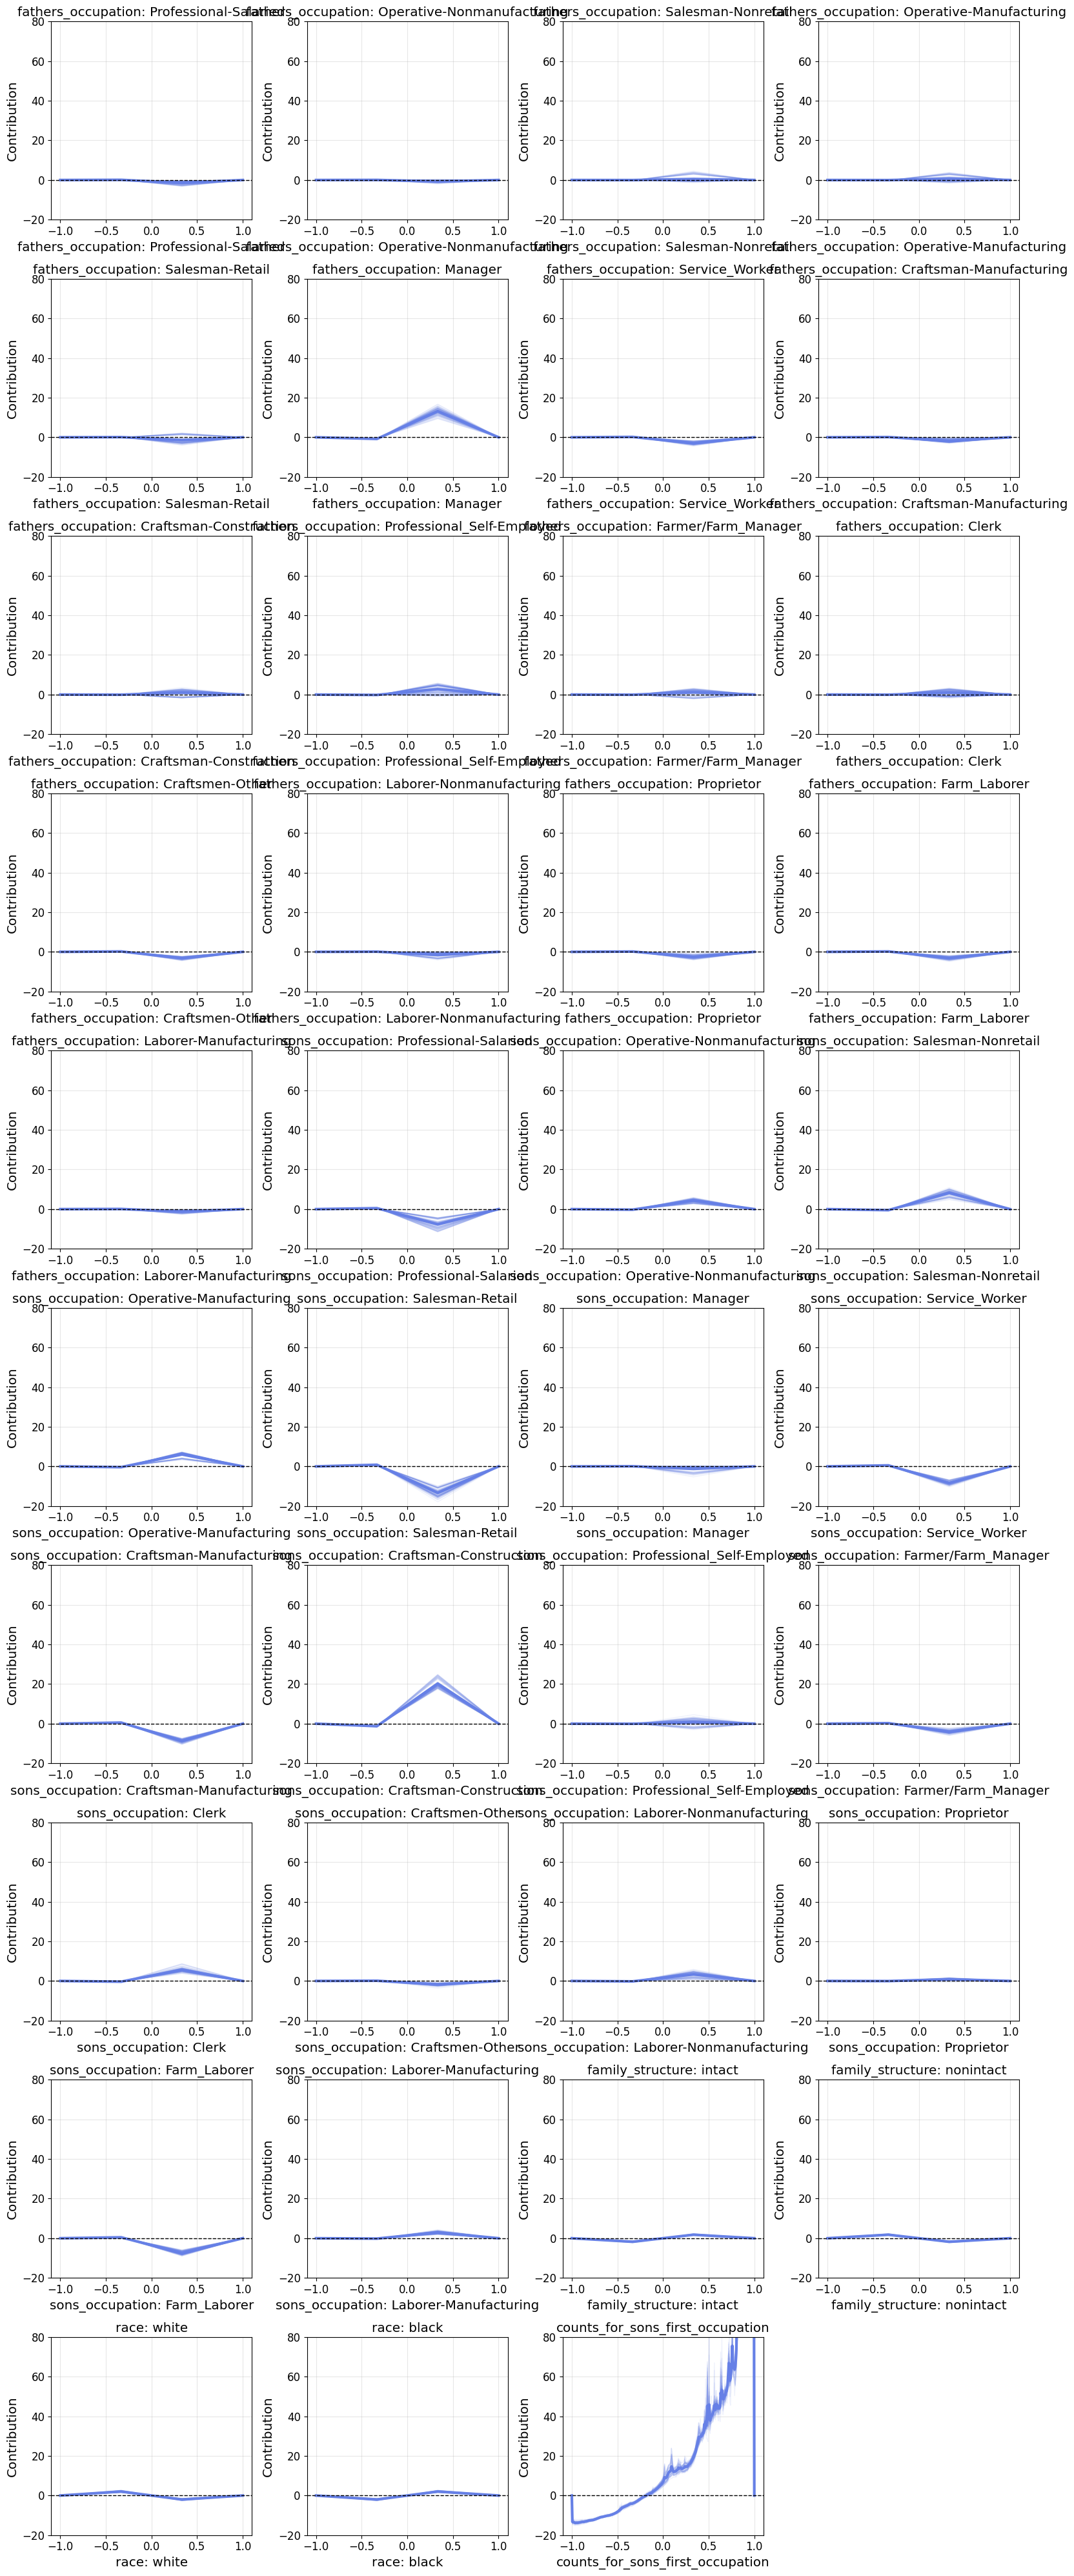

In [18]:
from utils import plot_ebm_shape_functions

# Plot average shape functions across all splits
fig = plot_ebm_shape_functions(
    column_names=column_names,
    all_shape_functions=all_shape_functions,
    y_limits=(-20, 80)
)
